# The Fourth Circle: Neural Networks, Part Four 
## Transformers II: Transformer Architecture

<br/>
Jiří Fejlek

2026-04-22
<br/>

It is finally time to implement a *transformer*: a revolutionary architecture introduced in the famous paper *Attention Is All You Need* [[1](#1)]. The transformer architecture is based on the attention mechanism [[2](#2)]; however, instead of using attention to enhance an RNN-based encoder-decoder architecture, it introduces attention as a part of a new feedforward encoder-decoder architecture without any recurrent layers. In addition, while transformers were intended for sequence-to-sequence text tasks, they have found a variety of applications, including computer vision, speech recognition, and reinforcement learning. 

## Table of Contents

- [Tatoeba Project Dataset](#tatoeba)
- [Multi-Head Attention](#mh_attention)
    - [Encoder-Decoder Model with Multi-Head Attention](#ed_mh_attention)
- [Self-Attention](#self_att)
- [Positional Encoding](#posit_enc)
- [Transformer Architecture](#transformer)
    - [Position-wise Feed-Forward Network](#pointwise_ffn)
    - [Add & Norm Layer](#addnorm)
    - [Encoder](#encoder)
    - [Decoder](#decoder)
    - [Transformer Implementation](#transformer_impl)
- [Training Encoder-Decoder Model with the Bahdanau Attention](#train)
- [References](#references)


## Tatoeba Project Dataset <a class="anchor" id="tatoeba"></a>

We will continue using the dataset of bilingual sentence pairs from https://www.manythings.org/anki/ based on the Tatoeba project https://tatoeba.org/en.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import math

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

import re
import collections
import os

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [3]:
def _preprocess(text):
    no_space = lambda char, prev_char: char in ',.!?' and prev_char != ' '
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text.lower())]
    return ''.join(out)

In [4]:
class Vocabulary: 

    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        
        # Flatten the list of tokens
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse = True)

        # The list of unique tokens, we ignore tokens with frequency lower than min_freq
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [token for token, freq in self.token_freqs if freq >= min_freq]))) 
        # convert tokens to indices
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
     
    def __len__(self):
        return len(self.idx_to_token)
    
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk) # return unknown token if not in the vocabulary
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]
    
    @property
    def unk(self): # index for the unknown token
        return self.token_to_idx['<unk>']

In [5]:
class Tatoeba:

    def _preprocess(self, text):
        
        # Insert space between words and punctuation marks
        no_space = lambda char, prev_char: char in ',.!?' and prev_char != ' '
        out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
               
               for i, char in enumerate(text.lower())]
        
        return ''.join(out)

    def truncate_pad(self, line, num_steps, padding_token):
        if len(line) > num_steps:
            return line[:num_steps]  # Truncate
        return line + [padding_token] * (num_steps - len(line))  # Pad
    
    def _read(self):
        
        data_dir = self.data_dir
        tatoeba_data = []
        
        with open(data_dir, encoding='utf-8') as file:
            lines = [line.rstrip() for line in file]

        for line in lines:
            line = _preprocess(line)
            idx = line.find("cc-by")
            tatoeba_data.append(line[:idx-1])
        
        lang1_text = []
        lang2_text = []
        
        for lines in tatoeba_data:
            words = lines.split('\t')
            
            if len(words) == 2:
                
                lang1_line = [t for t in f'{words[0]} <eos>'.split(' ') if t]
                lang2_line = [t for t in f'<bos> {words[1]} <eos>'.split(' ') if t]
                
                if len(lang1_line) > self.max_length + 1:
                    del lang1_line[self.max_length:-1]
                    
                if len(lang2_line) > self.max_length + 2:
                    del lang2_line[self.max_length+1:-1]
                    
                lang1_text.append(lang1_line)
                lang2_text.append(lang2_line)

        self.lang1_text = lang1_text
        self.lang2_text = lang2_text

    def _build(self):
        
        self._read()
        self.vocab_lang_1 = Vocabulary(self.lang1_text, min_freq = 2, reserved_tokens= ['<pad>'])
        self.vocab_lang_2 = Vocabulary(self.lang2_text, min_freq = 2, reserved_tokens= ['<pad>'])

        corpus_lang_1 = [self.vocab_lang_1[token] for token in self.lang1_text]
        corpus_lang_2 = [self.vocab_lang_2[token] for token in self.lang2_text]

        len_1 = torch.zeros(len(corpus_lang_1))
        for i in range(len(corpus_lang_1)):
            len_1[i] = len(corpus_lang_1[i])

        self.len_1 = len_1.long() 
            

        len_2 = torch.zeros(len(corpus_lang_2))
        for i in range(len(corpus_lang_2)):
            len_2[i] = len(corpus_lang_2[i])
            
        self.len_2 = len_2.long() - 1

        self.corpus_lang_1 = [self.truncate_pad(line, self.max_length + 1, self.vocab_lang_1['<pad>']) for line in corpus_lang_1]
        self.corpus_lang_2 = [self.truncate_pad(line, self.max_length + 2, self.vocab_lang_2['<pad>']) for line in corpus_lang_2]

        
        np.random.seed(0)
        rand_perm = np.random.permutation(range(len(self.corpus_lang_1))) 

        corpus_lang_1_train = [self.corpus_lang_1[i] for i in rand_perm[:self.num_train]]
        corpus_lang_2_train = [self.corpus_lang_2[i] for i in rand_perm[:self.num_train]]
        len_1_train = [self.len_1[i] for i in rand_perm[:self.num_train]]
        len_2_train = [self.len_2[i] for i in rand_perm[:self.num_train]]

        corpus_lang_1_test = [self.corpus_lang_1[i] for i in rand_perm[self.num_train:]]
        corpus_lang_2_test = [self.corpus_lang_2[i] for i in rand_perm[self.num_train:]]
        len_1_test = [self.len_1[i] for i in rand_perm[self.num_train:]]
        len_2_test = [self.len_2[i] for i in rand_perm[self.num_train:]]

        dataset_train = torch.utils.data.TensorDataset(*[torch.tensor(corpus_lang_1_train), torch.tensor(corpus_lang_2_train),len_1_train, len_2_train])
        dataset_test = torch.utils.data.TensorDataset(*[torch.tensor(corpus_lang_1_test), torch.tensor(corpus_lang_2_test),len_1_test, len_2_test])

        self.train_dataloader = torch.utils.data.DataLoader(dataset_train, self.batch_size, shuffle = True)
        self.test_dataloader = torch.utils.data.DataLoader(dataset_test, self.batch_size, shuffle = False)  


               
    def __init__(self, data_dir, num_train, batch_size, max_length):
        
        self.data_dir = data_dir
        self.num_train = num_train
        self.batch_size = batch_size
        self.max_length = max_length

        self._build()

In [6]:
Tatoeba_dataset = Tatoeba('D:/nine circles 2/ces.txt', num_train = 38000, batch_size = 250, max_length = 15) 

for X, Y, X_len, Y_len in Tatoeba_dataset.train_dataloader:
    print('X:', X, '\nY:', Y, '\nX_len:', X_len, '\nY_len:', Y_len)
    break

X: tensor([[4658, 2726, 2231,  ...,   53,   53,   53],
        [  74, 2280, 2780,  ...,   53,   53,   53],
        [2470, 1404,  218,  ...,   53,   53,   53],
        ...,
        [4577, 3932, 2132,  ...,   53,   53,   53],
        [2280, 1321, 5169,  ...,   53,   53,   53],
        [3034, 3120, 4965,  ...,   53,   53,   53]]) 
Y: tensor([[  38, 7124, 5777,  ...,   40,   40,   40],
        [  38, 1885, 1319,  ...,   40,   40,   40],
        [  38, 2930, 8432,  ...,   40,   40,   40],
        ...,
        [  38, 8029, 9544,  ...,   40,   40,   40],
        [  38, 1525, 1703,  ...,   40,   40,   40],
        [  38, 3826, 3381,  ...,   40,   40,   40]]) 
X_len: tensor([ 6, 10,  6,  8,  8,  8,  7,  8,  9, 11,  5,  6,  7, 10,  8, 11,  7,  8,
         5,  7,  8,  7,  6,  6,  8,  9, 10,  9,  7,  8,  4,  7,  8,  7,  6,  7,
         4,  9,  8,  6,  6,  6, 11,  5,  8,  7,  9,  7,  6, 10,  5,  6, 10,  5,
         9, 11,  8,  8,  9,  6,  4, 10,  6,  8,  6, 10,  6,  8,  6,  6,  7,  6,
         7, 1

In [7]:
X[0]

tensor([4658, 2726, 2231, 1405,   24,   52,   53,   53,   53,   53,   53,   53,
          53,   53,   53,   53])

In [8]:
X[0][:X_len[0]]

tensor([4658, 2726, 2231, 1405,   24,   52])

In [9]:
Y[0]

tensor([  38, 7124, 5777, 4015, 6923, 5435,   17,   39,   40,   40,   40,   40,
          40,   40,   40,   40,   40])

In [10]:
Y[0][1:][:Y_len[0]]

tensor([7124, 5777, 4015, 6923, 5435,   17,   39])

## Multi-Head Attention <a class="anchor" id="mh_attention"></a>

Before we introduce the transformer itself, we will implement *multi-head attention* which was proposed in the same paper as the transformer architecture [[1](#1)]. Instead of performing a single attention pooling, multi-head attention performs multiple independent attention poolings. 

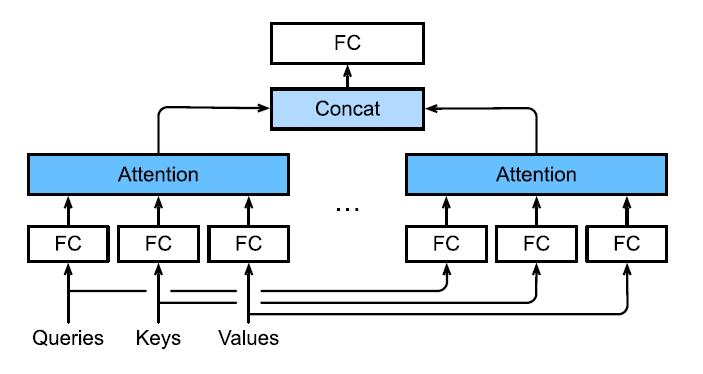

More specifically, a single *attention head* for a query $q$, keys $k$, nad values $v$ is defined as
$$ h_i = f(W_i^{(q)} q, W_i^{(k)} k, W_i^{(v)}v),$$
where $W_i^{(q)} \in \mathbb{R}^{p_q \times d_q}$, $W_i^{(k)} \in \mathbb{R}^{p_k \times d_k}$, $W_i^{(v)} \in \mathbb{R}^{p_v \times d_v}$  are some weights and $f$ is an attention pooling (e.g., additive attention or scaled dot-product attention). The output of the *multi-head attention* is then
$$ W_o [h_1, \ldots, h_{n_h}]^T \in\mathbb{R}^{p_o},$$
where $W_o \in \mathbb{R}^{p_o \times n_h p_q}$, $W_i^{(k)}.$ In other words, multi-head attention consists of transforming the original query, keys, and values with $n_h$ independent linear transformations and performing attention pooling on each of them. Then, the results are concatenated and transformed with the final linear layer.

Let us go through these computations step by step. First, we load a batch.

In [11]:
for X, Y, X_len, Y_len in Tatoeba_dataset.train_dataloader:
    break

In [12]:
X

tensor([[2149, 1404, 4181,  ...,   53,   53,   53],
        [2311, 2003, 5169,  ...,   53,   53,   53],
        [4596,  308, 3960,  ...,   53,   53,   53],
        ...,
        [2311,  643,   57,  ...,   53,   53,   53],
        [3997, 2141, 1819,  ...,   53,   53,   53],
        [4594, 4631, 4989,  ...,   53,   53,   53]])

In [13]:
X.size()

torch.Size([250, 16])

In [14]:
X_len

tensor([ 6, 13,  6, 12,  7,  4,  7,  7,  8, 11,  4,  7,  6,  6,  7,  5,  8,  6,
         7,  7,  7,  7,  7,  9,  6,  7,  9,  9, 15,  9,  9, 14, 11,  5, 10,  6,
         6,  7,  7,  7,  8, 10,  7, 10,  8,  8, 11, 11,  7,  3,  8,  7,  7,  7,
         8,  7,  5,  6,  8,  8,  9, 12,  5,  9,  9,  9,  7,  9,  8,  7,  6,  6,
         8,  6,  7, 12,  8,  7,  6,  7,  9, 10,  7,  7,  9,  5,  6,  8,  8,  8,
         9,  7,  4,  7,  9,  4,  7, 11,  8,  7,  7,  7,  9,  8,  7,  7,  9, 10,
         6,  5,  9,  9,  9,  5,  7,  6,  7,  6, 11,  7,  6, 12,  7, 12,  9, 11,
         7, 11, 15, 10, 13,  8,  8,  8, 10,  9,  8, 12,  8,  7,  6,  6,  5,  6,
         8,  9,  9,  7,  7, 11,  9,  6,  5,  8,  8,  6, 11,  8,  5,  6,  7,  9,
         8, 16,  9,  6, 11,  6, 11,  6,  7,  7,  6, 11,  9, 10,  6,  7,  6,  9,
         8,  7,  9, 11,  9, 11, 12, 14, 11,  5,  7,  6,  8,  7,  7, 11,  5,  6,
        10,  7,  9,  6,  9,  6,  9,  9,  5, 16,  6, 10,  8,  7,  6,  7,  5, 11,
         6,  6,  6,  7, 10,  8, 10,  7, 

In [15]:
X_len.size()

torch.Size([250])

We will follow our RNN-based encoder-decoder model with attention. Thence, we next obtain the outputs and the hidden state from the RNN encoder.

In [16]:
class Encoder(nn.Module): 
  
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout = 0):
        super().__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, hidden_size, num_layers, dropout = dropout)

    def forward(self, inputs):

        state = torch.zeros((self.num_layers, inputs.shape[0], self.hidden_size), device = inputs.device) 
        embeddings = self.embedding(inputs.T)
        
        outputs, state = self.rnn(embeddings, state)
        
        return outputs, state

In [17]:
hidden_size = 256
num_layers = 2
embed_size = 128
vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()

encoder = Encoder(vocab_size_1, embed_size, hidden_size, num_layers, dropout = 0)
enc_outputs, hidden_state = encoder(X)

We will use the encoder's outputs as keys and values.

In [18]:
values = enc_outputs.permute(1, 0, 2)
keys = enc_outputs.permute(1, 0, 2)
keys.size()

torch.Size([250, 16, 256])

We will again assume that the decoder's first hidden state is the encoder's last hidden state. Hence, we will set the queries as the encoder's hidden state.

In [19]:
queries = torch.unsqueeze(hidden_state[-1], dim=1)
queries.size()

torch.Size([250, 1, 256])

Now, we have all the inputs to compute the multi-head attention. We will assume $p_q = p_k = p_v = p_o/n_h$ [[2](#2)]; let us transform queries, keys, and values to the correct dimensions using the fully connected linear layers.

In [20]:
attention_size = 512 # attention_size = p_o = num_heads*p_q = num_heads*p_k = num_heads*p_v

W_q = nn.LazyLinear(attention_size, bias = False)
W_k = nn.LazyLinear(attention_size, bias = False)
W_v = nn.LazyLinear(attention_size, bias = False)

transf_queries = W_q(queries)  # batch_size x 1 x attention_size
transf_keys = W_k(keys)  # batch_size x input_seq_length x attention_size
transf_values = W_v(values)  # batch_size x input_seq_length x attention_size

In [21]:
transf_queries.size()

torch.Size([250, 1, 512])

In [22]:
transf_keys.size()

torch.Size([250, 16, 512])

In [23]:
transf_values.size()

torch.Size([250, 16, 512])

Next, we need to reshape the tensors to apply our attention model implementation (namely, the scaled dot-product attention). 

In [24]:
num_heads = 8

def transpose_qkv(X):
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)
    X = X.permute(0, 2, 1, 3)
    return X.reshape(-1, X.shape[2], X.shape[3])

To see how these elements are ordered, the function first separates the tensor's elements across the respective attention heads.

In [25]:
hk = transf_keys.reshape(transf_keys.shape[0], transf_keys.shape[1], num_heads, -1) # batch_size x input_seq_length x num_heads x (attention_size/num_heads)
hk.size()

torch.Size([250, 16, 8, 64])

In [26]:
transf_keys[0,0,0:128]

tensor([ 0.0259, -0.0140,  0.0124,  0.0259, -0.0270, -0.0135, -0.0274,  0.0132,
         0.0238,  0.0264, -0.0112,  0.0066, -0.0149,  0.0124,  0.0066, -0.0511,
        -0.0009, -0.0343,  0.0199, -0.0270,  0.0124, -0.0053, -0.0175, -0.0328,
         0.0084, -0.0046, -0.0155,  0.0122,  0.0372,  0.0533,  0.0232,  0.0230,
         0.0536,  0.0112, -0.0428,  0.0002,  0.0088,  0.0681,  0.0439,  0.0230,
         0.0674,  0.0295,  0.0336,  0.0184, -0.0227, -0.0465,  0.0391, -0.0327,
         0.0047, -0.0319, -0.0283,  0.0235,  0.0072,  0.0347, -0.0190,  0.0596,
         0.0097, -0.0076,  0.0091, -0.0270,  0.0227,  0.0025,  0.0172,  0.0022,
         0.0513,  0.0565,  0.0310, -0.0203, -0.0495, -0.0104,  0.0599,  0.0532,
        -0.0020,  0.0178,  0.0043, -0.0118, -0.0309,  0.0478, -0.0230, -0.0254,
         0.0454,  0.0509, -0.0259,  0.0481, -0.0141, -0.0138,  0.0193,  0.0122,
         0.0049, -0.0393, -0.0124, -0.0262,  0.0022, -0.0141, -0.0398,  0.0614,
        -0.0127,  0.0010,  0.0174, -0.03

In [27]:
hk[0, 0, 0,:]

tensor([ 0.0259, -0.0140,  0.0124,  0.0259, -0.0270, -0.0135, -0.0274,  0.0132,
         0.0238,  0.0264, -0.0112,  0.0066, -0.0149,  0.0124,  0.0066, -0.0511,
        -0.0009, -0.0343,  0.0199, -0.0270,  0.0124, -0.0053, -0.0175, -0.0328,
         0.0084, -0.0046, -0.0155,  0.0122,  0.0372,  0.0533,  0.0232,  0.0230,
         0.0536,  0.0112, -0.0428,  0.0002,  0.0088,  0.0681,  0.0439,  0.0230,
         0.0674,  0.0295,  0.0336,  0.0184, -0.0227, -0.0465,  0.0391, -0.0327,
         0.0047, -0.0319, -0.0283,  0.0235,  0.0072,  0.0347, -0.0190,  0.0596,
         0.0097, -0.0076,  0.0091, -0.0270,  0.0227,  0.0025,  0.0172,  0.0022],
       grad_fn=<SelectBackward0>)

In [28]:
hk[0, 0, 1,:]

tensor([ 0.0513,  0.0565,  0.0310, -0.0203, -0.0495, -0.0104,  0.0599,  0.0532,
        -0.0020,  0.0178,  0.0043, -0.0118, -0.0309,  0.0478, -0.0230, -0.0254,
         0.0454,  0.0509, -0.0259,  0.0481, -0.0141, -0.0138,  0.0193,  0.0122,
         0.0049, -0.0393, -0.0124, -0.0262,  0.0022, -0.0141, -0.0398,  0.0614,
        -0.0127,  0.0010,  0.0174, -0.0312,  0.0350,  0.0074, -0.0256, -0.0374,
         0.0232,  0.0458,  0.0188,  0.0188,  0.0157, -0.0235,  0.0358, -0.0173,
         0.0126,  0.0550, -0.0059,  0.0087, -0.0147,  0.0300,  0.0032,  0.0131,
        -0.0264, -0.0176, -0.0206, -0.0337,  0.0150,  0.0496, -0.0118,  0.0282],
       grad_fn=<SelectBackward0>)

Then, it reshapes the tensor in such a way that each element (wrt. first dimension) corresponds to a single attention head. The entries are also sorted by their index in the batch.

In [29]:
hk = hk.permute(0, 2, 1, 3)
hk = hk.reshape(-1, hk.shape[2], hk.shape[3])
hk.size()  # (batch_size * num_heads) x input_seq_length x (attention_size/num_heads)

torch.Size([2000, 16, 64])

In [30]:
hk[0,0,:]

tensor([ 0.0259, -0.0140,  0.0124,  0.0259, -0.0270, -0.0135, -0.0274,  0.0132,
         0.0238,  0.0264, -0.0112,  0.0066, -0.0149,  0.0124,  0.0066, -0.0511,
        -0.0009, -0.0343,  0.0199, -0.0270,  0.0124, -0.0053, -0.0175, -0.0328,
         0.0084, -0.0046, -0.0155,  0.0122,  0.0372,  0.0533,  0.0232,  0.0230,
         0.0536,  0.0112, -0.0428,  0.0002,  0.0088,  0.0681,  0.0439,  0.0230,
         0.0674,  0.0295,  0.0336,  0.0184, -0.0227, -0.0465,  0.0391, -0.0327,
         0.0047, -0.0319, -0.0283,  0.0235,  0.0072,  0.0347, -0.0190,  0.0596,
         0.0097, -0.0076,  0.0091, -0.0270,  0.0227,  0.0025,  0.0172,  0.0022],
       grad_fn=<SelectBackward0>)

In [31]:
hk[1,0,:]

tensor([ 0.0513,  0.0565,  0.0310, -0.0203, -0.0495, -0.0104,  0.0599,  0.0532,
        -0.0020,  0.0178,  0.0043, -0.0118, -0.0309,  0.0478, -0.0230, -0.0254,
         0.0454,  0.0509, -0.0259,  0.0481, -0.0141, -0.0138,  0.0193,  0.0122,
         0.0049, -0.0393, -0.0124, -0.0262,  0.0022, -0.0141, -0.0398,  0.0614,
        -0.0127,  0.0010,  0.0174, -0.0312,  0.0350,  0.0074, -0.0256, -0.0374,
         0.0232,  0.0458,  0.0188,  0.0188,  0.0157, -0.0235,  0.0358, -0.0173,
         0.0126,  0.0550, -0.0059,  0.0087, -0.0147,  0.0300,  0.0032,  0.0131,
        -0.0264, -0.0176, -0.0206, -0.0337,  0.0150,  0.0496, -0.0118,  0.0282],
       grad_fn=<SelectBackward0>)

Indeed, notice that the ninth element corresponds to the input for the first head for the second observation in the batch.

In [32]:
transf_keys[1,0,0:64]

tensor([ 0.0276, -0.0172, -0.0503, -0.0192, -0.0610, -0.0319, -0.0639,  0.0055,
         0.0184,  0.0999,  0.0115, -0.0089, -0.0045,  0.0150,  0.0263,  0.0099,
        -0.0758,  0.0397,  0.0251, -0.0220,  0.0064,  0.0162, -0.0286, -0.0033,
        -0.0287,  0.0136, -0.0448, -0.0119, -0.0735, -0.0392,  0.0466,  0.0036,
         0.0180,  0.0104, -0.0151,  0.0194, -0.0125, -0.0072, -0.0428,  0.0514,
         0.0324,  0.0272,  0.0145, -0.0024,  0.0234, -0.0542,  0.0260, -0.0809,
         0.0289,  0.0154, -0.0039, -0.0023, -0.0125,  0.0240, -0.0293,  0.0403,
        -0.0271,  0.0254,  0.0066, -0.0407,  0.0191, -0.0160,  0.0589,  0.0067],
       grad_fn=<SliceBackward0>)

In [33]:
hk[8,0,:]

tensor([ 0.0276, -0.0172, -0.0503, -0.0192, -0.0610, -0.0319, -0.0639,  0.0055,
         0.0184,  0.0999,  0.0115, -0.0089, -0.0045,  0.0150,  0.0263,  0.0099,
        -0.0758,  0.0397,  0.0251, -0.0220,  0.0064,  0.0162, -0.0286, -0.0033,
        -0.0287,  0.0136, -0.0448, -0.0119, -0.0735, -0.0392,  0.0466,  0.0036,
         0.0180,  0.0104, -0.0151,  0.0194, -0.0125, -0.0072, -0.0428,  0.0514,
         0.0324,  0.0272,  0.0145, -0.0024,  0.0234, -0.0542,  0.0260, -0.0809,
         0.0289,  0.0154, -0.0039, -0.0023, -0.0125,  0.0240, -0.0293,  0.0403,
        -0.0271,  0.0254,  0.0066, -0.0407,  0.0191, -0.0160,  0.0589,  0.0067],
       grad_fn=<SelectBackward0>)

Overall, we get the following transformed queries, keys, and values.

In [34]:
head_queries = transpose_qkv(transf_queries) # (batch_size * num_heads) x 1 x (attention_size/num_heads)
head_keys = transpose_qkv(transf_keys) # (batch_size * num_heads) x input_seq_length x (attention_size/num_heads)
head_values = transpose_qkv(transf_values) # (batch_size * num_heads) x input_seq_length x (attention_size/num_heads)

In [35]:
head_queries.size()

torch.Size([2000, 1, 64])

In [36]:
head_keys.size()

torch.Size([2000, 16, 64])

In [37]:
head_values.size()

torch.Size([2000, 16, 64])

Next, we prepare the input lengths by repeating each *X_len* element *num_heads* times.

In [38]:
head_X_len = torch.repeat_interleave(X_len, repeats = num_heads, dim=0)

Finally, we have all the tensors ready to compute the scaled dot-product attentions.

In [39]:
class DotProductAttention(nn.Module):
    
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, queries, keys, values, valid_lens = None):
        
        d = queries.shape[-1]
         
        # Queries: (batch_size, number of queries, q_d)
        # Keys: (batch_size, number of keys = number of values, k_d)
        # Values: (batch_size, number of keys = number of values, v_d)
        # Valid_lens: (batch_size) or (batch_size, number of queries)
        
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)

        return torch.bmm(self.dropout(self.attention_weights), values)

def masked_softmax(X, valid_lens): 
    
    def _sequence_mask(X, valid_len, value = 0):
        maxlen = X.size(1)
        mask = torch.arange((maxlen), dtype = torch.float32, device = X.device)[None, :] < valid_len[:, None]
        X[~mask] = value
        return X
        
    if valid_lens is None:
        return nn.functional.softmax(X, dim = -1)
    else:
        shape = X.shape
        
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)

        X = _sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

attention = DotProductAttention(dropout = 0)
attention_output = attention(head_queries, head_keys, head_values, head_X_len)
attention_output.size()

torch.Size([2000, 1, 64])

We can access the corresponding attention weights $\alpha(q,k_i)$ as follows.

In [40]:
attention.attention_weights

tensor([[[0.1665, 0.1663, 0.1665,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.1668, 0.1657, 0.1667,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.1664, 0.1652, 0.1659,  ..., 0.0000, 0.0000, 0.0000]],

        ...,

        [[0.1668, 0.1671, 0.1673,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.1666, 0.1665, 0.1672,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.1668, 0.1671, 0.1662,  ..., 0.0000, 0.0000, 0.0000]]],
       grad_fn=<SoftmaxBackward0>)

In [41]:
attention.attention_weights.size()

torch.Size([2000, 1, 16])

Lastly, we need to reorder the calculated attention values back to their original shape by reversing the previous transformations, and then apply the final linear layer.

In [42]:
def transpose_output(X):
        
        X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
        X = X.permute(0, 2, 1, 3)
        return X.reshape(X.shape[0], X.shape[1], -1)

In [43]:
transpose_output(attention_output).size()

torch.Size([250, 1, 512])

In [44]:
W_o = nn.LazyLinear(attention_size, bias = False)
W_o(transpose_output(attention_output)).size()

torch.Size([250, 1, 512])

Overall, we get the following implementation of the multi-head attention [[3](#3)]. 

In [45]:
class MultiHeadAttention(nn.Module): 

    def transpose_qkv(self, X):
        
        X = X.reshape(X.shape[0], X.shape[1], self.num_heads, -1)
        X = X.permute(0, 2, 1, 3)
        return X.reshape(-1, X.shape[2], X.shape[3])
        
    def transpose_output(self, X):
        
        X = X.reshape(-1, self.num_heads, X.shape[1], X.shape[2])
        X = X.permute(0, 2, 1, 3)
        return X.reshape(X.shape[0], X.shape[1], -1)
        
    def __init__(self, attention_size, num_heads, dropout, bias = False):
        
        super().__init__()
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.LazyLinear(attention_size, bias = bias)
        self.W_k = nn.LazyLinear(attention_size, bias = bias)
        self.W_v = nn.LazyLinear(attention_size, bias = bias)
        self.W_o = nn.LazyLinear(attention_size, bias = bias)
        
    def forward(self, queries, keys, values, valid_lens):
        
        queries = self.transpose_qkv(self.W_q(queries))
        keys = self.transpose_qkv(self.W_k(keys))
        values = self.transpose_qkv(self.W_v(values))
        
        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens, repeats=self.num_heads, dim=0)
            
        output = self.attention(queries, keys, values, valid_lens)
        output_concat = self.transpose_output(output)
            
        return self.W_o(output_concat)

In [46]:
multihead_attention = MultiHeadAttention(512, 8, dropout = 0)

In [47]:
multihead_attention(queries, keys, values, X_len)

tensor([[[ 0.0187,  0.0010,  0.0212,  ..., -0.0118,  0.0126, -0.0094]],

        [[ 0.0292,  0.0035, -0.0230,  ...,  0.0009, -0.0176, -0.0058]],

        [[ 0.0466,  0.0095, -0.0263,  ...,  0.0255,  0.0122, -0.0252]],

        ...,

        [[ 0.0017, -0.0148,  0.0088,  ..., -0.0146, -0.0196, -0.0065]],

        [[ 0.0182,  0.0020,  0.0436,  ..., -0.0010,  0.0141,  0.0057]],

        [[ 0.0307,  0.0065,  0.0122,  ...,  0.0120, -0.0416,  0.0285]]],
       grad_fn=<UnsafeViewBackward0>)

In [48]:
multihead_attention(queries, keys, values, X_len).size()

torch.Size([250, 1, 512])

In [49]:
multihead_attention.attention.attention_weights

tensor([[[0.1674, 0.1663, 0.1664,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.1660, 0.1668, 0.1668,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.1658, 0.1673, 0.1683,  ..., 0.0000, 0.0000, 0.0000]],

        ...,

        [[0.1665, 0.1659, 0.1663,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.1657, 0.1666, 0.1666,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.1651, 0.1659, 0.1669,  ..., 0.0000, 0.0000, 0.0000]]],
       grad_fn=<SoftmaxBackward0>)

In [50]:
multihead_attention.attention.attention_weights.size()

torch.Size([2000, 1, 16])

### Encoder-Decoder Model with Multi-Head Attention <a class="anchor" id="ed_mh_attention"></a>

Let us implement an encoder-decoder model with a multi-head attention mechanism. The implementation itself is a straightforward modification of our previous implementation of the encoder-decoder model with attention. 

In [51]:
class Attention_decoder(nn.Module): 
  
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, attention_size, num_heads, dropout = 0):
        super().__init__()

        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.attention = MultiHeadAttention(attention_size, num_heads, dropout, bias = False)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + attention_size, hidden_size, num_layers, dropout = dropout)
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, inputs, states):
        
        hidden_state, enc_output, valid_len = states

        embeddings = self.embedding(inputs.T)
        dec_output = []
        
        for y in embeddings:
            query = torch.unsqueeze(hidden_state[-1], dim=1) # query: (batch_size, 1, num_hiddens)
            context = self.attention(query, enc_output.permute(1, 0, 2), enc_output.permute(1, 0, 2), valid_len) #context: (batch_size, 1, num_hiddens)
            context_y = torch.cat((context, torch.unsqueeze(y, dim=1)), dim=-1) #concat inputs and context 
            output, hidden_state = self.rnn(context_y.permute(1, 0, 2), hidden_state)
            
            dec_output.append(output)

        outputs = self.linear(torch.cat(dec_output, dim=0))
        
        return outputs, [enc_output, hidden_state, valid_len]

In [52]:
class Encoder_Attention_decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, hidden_size_attention, num_heads, dropout = 0):
        super().__init__()

        self.encoder = Encoder(vocab_size[0], embed_size, hidden_size, num_layers, dropout = dropout)
        self.decoder = Attention_decoder(vocab_size[1], embed_size, hidden_size, num_layers, hidden_size_attention, num_heads, dropout = dropout)

    def forward(self, input_X, input_Y, X_len):
        
        enc_output, hidden_state = self.encoder(input_X)
        dec_output, _ = self.decoder(input_Y, [hidden_state, enc_output, X_len]) 

        return dec_output

We can check that the batch is processed correctly.

In [53]:
# RNN parameters
hidden_size = 256
num_layers = 2
embed_size = 128

# multi-head attention model parameters
hidden_size_attention = 512
num_heads = 8

vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()

encoder_decoder = Encoder_Attention_decoder([vocab_size_1, vocab_size_2], embed_size, hidden_size, num_layers, hidden_size_attention, num_heads)

output = encoder_decoder(X, Y[:,:-1], X_len)
output.size()

torch.Size([16, 250, 9634])

We can compute the masked log-loss as follows.

In [54]:
def masked_loss(loss, Y_hat, Y, Y_len):
    
    loss_all = cross_entropy_loss(Y_hat, Y[:,1:])
    loss = 0

    for i in range(loss_all.size()[0]):
        loss = loss + (loss_all[i][:Y_len[i]]).mean()

    return loss/len(Y)

In [55]:
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
loss = masked_loss(cross_entropy_loss, output.permute(1, 2, 0), Y, Y_len)
loss

tensor(9.1966, grad_fn=<DivBackward0>)

Let us implement the training loop, and we will train the model on English-Czech sentence pairs.

In [56]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler, max_norm):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    size_train = 0

    
    for batch, (X, Y, X_len, Y_len) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        Y = Y.to(cuda_device)
        X_len = X_len.to(cuda_device)
        Y_len = Y_len.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X, Y[:,:-1], X_len) # forward pass
        loss = masked_loss(loss_fn, pred_logits.permute(1, 2, 0), Y, Y_len) # loss evaluation 
        #loss = loss_fn(pred_logits.permute(1, 2, 0), Y[:,1:]) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm) # gradient clipping
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
           
    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        size_test = 0
        
        for batch, (X_test, Y_test, X_len_test, Y_len_test) in enumerate(test_data_loader):

            state = None
            X_test = X_test.to(cuda_device)
            Y_test = Y_test.to(cuda_device)
            X_len_test = X_len_test.to(cuda_device)
            Y_len_test = Y_len_test.to(cuda_device)
            
            pred_logits_test = model(X_test, Y_test[:,:-1], X_len_test)
            
            loss_sum_test = loss_sum_test + masked_loss(loss_fn, pred_logits_test.permute(1, 2, 0), Y_test, Y_len_test)*len(X_test)
            #loss_sum_test = loss_sum_test + loss_fn(pred_logits_test.permute(1, 2, 0), Y_test[:,1:])*len(X_test)

            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0]

In [57]:
torch.manual_seed(123)

# data loader
Tatoeba_dataset = Tatoeba('D:/nine circles 2/ces.txt', num_train = 38000, batch_size = 250, max_length = 15) 
Tatoeba_train_loader = Tatoeba_dataset.train_dataloader
Tatoeba_test_loader = Tatoeba_dataset.test_dataloader


embed_size = 256
vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()

hidden_size = 256
num_layers = 2

hidden_size_attention = 512
num_heads = 8


encoder_decoder_cuda = Encoder_Attention_decoder([vocab_size_1, vocab_size_2], embed_size, hidden_size, num_layers, hidden_size_attention, num_heads).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(encoder_decoder_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[200], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
max_norm = 10

n_epochs = 300

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(Tatoeba_train_loader, Tatoeba_test_loader, encoder_decoder_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

5653.545155763626


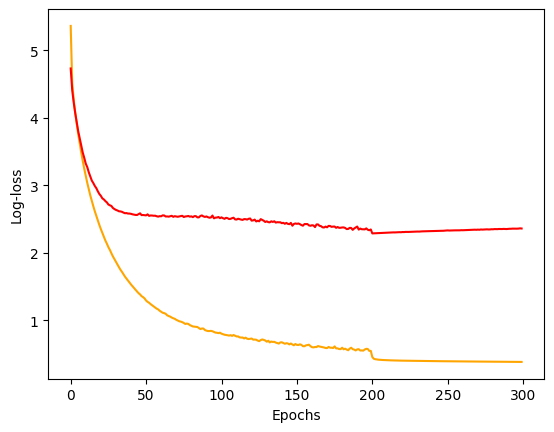

In [58]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [59]:
loss_epochs_train[299]

0.3835609555244446

In [60]:
loss_epochs_test[299]

2.3588814735412598

In [61]:
loss_epochs_test.min()

2.2865219116210938

Let us evaluate the model using BLEU. As usual, we can consider greedy and beam search prediction strategies.

In [62]:
for X, Y, X_len, Y_len in Tatoeba_dataset.test_dataloader:
    break

In [63]:
def predict_greedy(model, input_X, input_Y_init, X_len, num_steps):

        input_Y = input_Y_init
        prefix = input_Y_init
        enc_output, hidden_state = model.encoder(input_X)
        
        for i in range(num_steps): 

            output, states = model.decoder(input_Y, [hidden_state, enc_output, X_len])
            hidden_state = states[1]
            input_Y = output.argmax()[None][None]
            prefix = torch.cat((prefix,input_Y),0)

        return prefix.flatten()

In [64]:
bos_token = torch.tensor(Tatoeba_dataset.vocab_lang_2['<bos>'])
bos_token = bos_token[None][None]

greedy_pred = predict_greedy(encoder_decoder_cuda, X[0][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[0][None].to(cuda_device), 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(greedy_pred)

['<bos>',
 'nic',
 'o',
 'nic',
 'nevím',
 '.',
 '<eos>',
 'nevím',
 '.',
 '<eos>',
 'nevím']

In [65]:
def predict_beam(model, input_X, input_Y_init, X_len, num_steps, beam_size):

        with torch.no_grad():
            
            input_Y = input_Y_init
            enc_output , hidden_state = model.encoder(input_X)
    
            output, state = model.decoder(input_Y, [hidden_state, enc_output, X_len])
            hidden_state = state[1]

            sort_by_prob = torch.sort(torch.nn.functional.softmax(output.flatten(), dim = 0),descending  = True)
                
            # predicted sequences
            pred_token_seq = torch.zeros([beam_size, num_steps], device = input_X.device).long() 
            pred_token_seq[:,0] = sort_by_prob[1][:beam_size]

            # probabilities
            prob_seq = sort_by_prob[0][:beam_size]

            # hidden states             
            hidden_states_seq = hidden_state.repeat([1,beam_size,1])
            enc_output_seq = enc_output.repeat([1,beam_size,1])
            X_len_seq = X_len.repeat([1,beam_size,1])
            
            for i in range(1, num_steps):
            
                outputs, states = model.decoder(pred_token_seq[:,i-1].reshape([beam_size,1]), [hidden_states_seq, enc_output_seq, X_len_seq])
                hidden_states = states[1]

                pred_token_seq_new = torch.zeros([beam_size, num_steps], device = input_X.device).long() 

                output_0_sort_by_prob = torch.sort(torch.nn.functional.softmax(outputs[:,0,:].flatten(), dim = 0),descending  = True)

                pred_token_seq_new[:,0:i] =  pred_token_seq[0,0:i]
                pred_token_seq_new[:,i] = output_0_sort_by_prob[1][:beam_size]
                
                prob_seq_new = prob_seq[0]*output_0_sort_by_prob[0][:beam_size]
                hidden_states_seq = hidden_states[:,0,:][:,None,:].repeat([1,beam_size,1])

                for j in range(1, beam_size):
                
                    output_j_sort_by_prob = torch.sort(torch.nn.functional.softmax(outputs[:,j,:].flatten(), dim = 0),descending  = True)

                    for k in range(beam_size):

                        prob_cand = prob_seq[j]*output_j_sort_by_prob[0][k]
                    
                        for l in range(beam_size):
                        
                            if prob_cand > prob_seq_new[l]:
                                prob_seq_new[l] = prob_cand
                                pred_token_seq_new[l,0:i] = pred_token_seq[j,0:i]
                                pred_token_seq_new[l,i] = output_j_sort_by_prob[1][k]
                                hidden_states_seq[:,l,:] = hidden_states[:,j,:]
                                break

                        if (l == beam_size):
                            break
                            
                prob_seq = prob_seq_new
                pred_token_seq = pred_token_seq_new
                
        # return outputs, states
        return pred_token_seq, prob_seq 

In [66]:
pred_token_seq, prob_pred = predict_beam(encoder_decoder_cuda, X[0][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[0][None].to(cuda_device), num_steps = 10, beam_size = 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])

['nic', 'o', 'nic', 'nevím', '.', '<eos>', 'nevím', '.', '<eos>', 'nevím']

In [67]:
def BLEU(pred_tokens, label_tokens, k): 

    len_pred, len_label = len(pred_tokens), len(label_tokens)
    score = math.exp(min(0, 1 - len_label / len_pred))
    
    for n in range(1, min(k, len_pred) + 1):
        num_matches, label_subs = 0, collections.defaultdict(int)
        for i in range(len_label - n + 1):
            label_subs[' '.join(label_tokens[i: i + n])] += 1
        for i in range(len_pred - n + 1):
            if label_subs[' '.join(pred_tokens[i: i + n])] > 0:
                num_matches += 1
                label_subs[' '.join(pred_tokens[i: i + n])] -= 1
    score *= math.pow(num_matches / (len_pred - n + 1), math.pow(0.5, n))
    return score

The BLEU scores on the test set are as follows.

In [68]:
bleu_score = []

for X, Y, X_len, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq = predict_greedy(encoder_decoder_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[i][None].to(cuda_device), num_steps = 15)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq)
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [69]:
sum(bleu_score)/len(bleu_score)

0.3273503629328733

In [70]:
bleu_score = []

for X, Y, X_len, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq, _ = predict_beam(encoder_decoder_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[i][None].to(cuda_device), num_steps = 15, beam_size = 5)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [71]:
sum(bleu_score)/len(bleu_score)

0.3353365313349809

The beam search predictions are a bit better, as expected. Moreover, the obtained scores are slightly higher (about 0.01) than our previous encoder-decode model with additive attention. 

## Self-Attention <a class="anchor" id="self_att"></a>

The transformer model does not include any recurrent layers; thus, neither the encoder nor the decoder uses hidden states to process sequences. Instead, the transformer uses *self-attention* [[1](#1)]. The tokens are directly fed into an attention mechanism (the tokens themselves serve as queries, keys, and values), and each token attends to every other token.

For input tokens $(x_1, \ldots, x_n)$, the self-attention $(y_1, \ldots, y_n)$ is simply
$$ y_i = f(x_i, (x_1, x_1), (x_2, x_2), \ldots, (x_n, x_n)).$$
For example, we could get the following self-attention values for the first batch.

In [72]:
for X, Y, X_len, Y_len in Tatoeba_dataset.train_dataloader:
    break

attention_size = 256
embed_size = 128
num_heads = 8

vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()

attention = MultiHeadAttention(attention_size, num_heads, 0)
embedding = nn.Embedding(vocab_size_1, embed_size)

embed_X = embedding(X)
attention(embed_X, embed_X, embed_X, X_len)

tensor([[[ 0.2876,  0.2012, -0.0740,  ..., -0.0426,  0.1818, -0.0071],
         [ 0.2488,  0.1185, -0.1056,  ..., -0.1119,  0.1563, -0.0383],
         [ 0.2752,  0.1997, -0.0383,  ..., -0.0091,  0.2260, -0.0076],
         ...,
         [ 0.2781,  0.1935, -0.0942,  ..., -0.0975,  0.1454, -0.0541],
         [ 0.2781,  0.1935, -0.0942,  ..., -0.0975,  0.1454, -0.0541],
         [ 0.2781,  0.1935, -0.0942,  ..., -0.0975,  0.1454, -0.0541]],

        [[ 0.0310, -0.0506, -0.0578,  ..., -0.2254,  0.1125,  0.1061],
         [ 0.0527, -0.0356, -0.0883,  ..., -0.1738,  0.1474,  0.1393],
         [ 0.0739, -0.0403, -0.0641,  ..., -0.1846,  0.1136,  0.1650],
         ...,
         [ 0.0325, -0.0640, -0.1054,  ..., -0.1697,  0.1235,  0.1594],
         [ 0.1179, -0.0866, -0.0456,  ..., -0.2511,  0.1260,  0.1511],
         [ 0.1179, -0.0866, -0.0456,  ..., -0.2511,  0.1260,  0.1511]],

        [[-0.0308,  0.0594,  0.0262,  ...,  0.0116,  0.0712, -0.1253],
         [-0.0192,  0.0489, -0.0209,  ...,  0

In [73]:
attention(embed_X, embed_X, embed_X, X_len).size() 

torch.Size([250, 16, 256])

We can compare the self-attention mechanism with the other two main ways of processing a sequence: a recurrent layer and a convolution layer [[3](#3)].

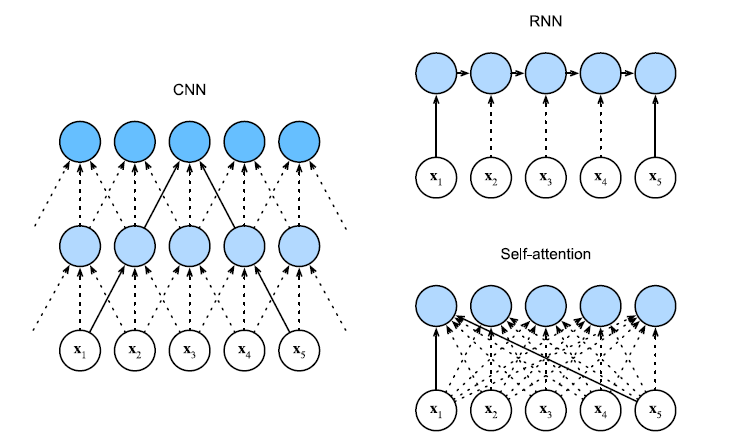

Similar to convolutional layers, self-attention is a feed-forward design (and thus easily parallelizable like CNNs). Unlike CNNs, all tokens attend to each other, whereas in CNNs, attention is limited by the size of receptive fields defined by kernel sizes. We mentioned this earlier when discussing CNNs: they excel at detecting local patterns in the signal but can struggle to learn long-term dependencies.

Of course, there is a trade-off between the ability of self-attention for all tokens to attend to each other and the computational complexity in each layer [[3](#3)].

* CNN: sequence length $n$, kernel of dimension $k$, input channels = output channels  =  $d$ $\implies$ computational complexity $O(nkd^2)$
* RNN: sequence length $n$, hidden state of dimension $d$ $\implies$ computational complexity $O(nd^2)$
* S-A: sequence length $n$, tokens represnted with embedding of dimension $d$  $\implies$ computational complexity $O(n^2d)$

We observe that, unlike RNNs and CNNs, the computational complexity of self-attention is quadratic in the length of the input sequence $n$. This means that the self-attention-based architectures can be prohibitively slow for very long sequences [[3](#3)]. 

## Positional Encoding <a class="anchor" id="posit_enc"></a>

Unlike RNNs, self-attention does not capture token order. Consequently, transformers use additional embeddings to represent the order of tokens, known as *positional encoding*. In our implementation, we will use sine and cosine positional encoding from [[1](#1)]. Let $X \in \mathbb{R}^{n \times d}$ be a matrix of token embeddings. The positional embedding matrix $P \in \mathbb{R}^{n \times d}$ has even collumns defined as
$$ p_{i,2j} = \text{sin}\left(\frac{i}{10000^{2j/d}} \right)$$
and odd columns as 
$$ p_{i,2j+1} = \text{cos}\left(\frac{i}{10000^{2j/d}} \right).$$
The final encoding of the input is then defined as $X + P$. 

Let us compute the matrix of positional encodings.

In [74]:
class PositionalEncoding(nn.Module): 
    
    def __init__(self, encoding_dim, dropout, max_len = 1000):
        
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        
        self.P = torch.zeros((1, max_len, encoding_dim))
        X = torch.arange(max_len, dtype = torch.float32).reshape(-1, 1) / torch.pow(10000, torch.arange(0, encoding_dim, 2, dtype=torch.float32) / encoding_dim)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)
        
    def forward(self, X):
        
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)

In [75]:
encoding_dim = 256
max_len = 15

pos_encoding = PositionalEncoding(encoding_dim, 0, max_len)
pos_encoding.P.size()

torch.Size([1, 15, 256])

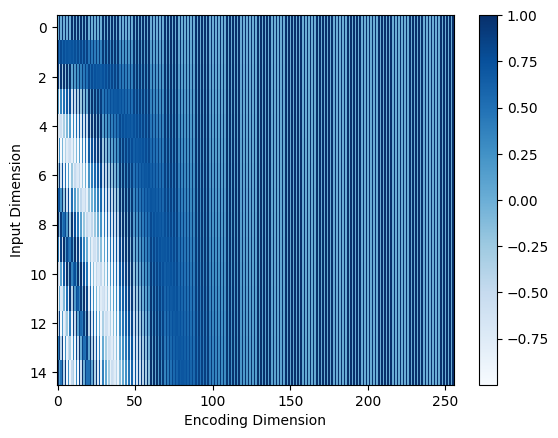

In [76]:
heatmap = plt.imshow(pos_encoding.P[0,:,:], cmap= plt.cm.Blues, interpolation='nearest', aspect='auto')
plt.colorbar(heatmap)
plt.xlabel("Encoding Dimension")
plt.ylabel("Input Dimension");

We can see from the coefficient heatmap that the positional encoding includes absolute positional information by adding a base signal corresponding to the zero position. In addition, for any fixed position offset $\delta$, the positional encoding of $i+\delta$ can be represented as a linear function of positional encoding at position $i$
$$ \begin{pmatrix}
\text{ cos } \delta\omega_j & \text{sin } \delta\omega_j\\
-\text{sin } \delta\omega_j & \text{cos } \delta\omega_j
\end{pmatrix} \begin{pmatrix}
p_{i,2j}\\
p_{i,2j+1}
\end{pmatrix} = \begin{pmatrix}
p_{i+\delta,2j}\\
p_{i+\delta,2j+1}
\end{pmatrix}.$$
Thus, the authors of [[1](#1)] hypothesized that this positional encoding would allow the model to easily learn to learn relative positions. 

We can also notice that the positional encoding has almost the same coefficient values in higher dimensions (it switches between 0 and 1). i.e., in the final encoding, the later dimensions are mostly just dedicated to the word embeddings.

In [77]:
pos_encoding.P[:,:,150]

tensor([[0.0000, 0.0045, 0.0091, 0.0136, 0.0181, 0.0227, 0.0272, 0.0317, 0.0362,
         0.0408, 0.0453, 0.0498, 0.0544, 0.0589, 0.0634]])

In [78]:
pos_encoding.P[:,:,151]

tensor([[1.0000, 1.0000, 1.0000, 0.9999, 0.9998, 0.9997, 0.9996, 0.9995, 0.9993,
         0.9992, 0.9990, 0.9988, 0.9985, 0.9983, 0.9980]])

In [79]:
pos_encoding.P[:,:,250]

tensor([[0.0000, 0.0001, 0.0002, 0.0004, 0.0005, 0.0006, 0.0007, 0.0009, 0.0010,
         0.0011, 0.0012, 0.0014, 0.0015, 0.0016, 0.0017]])

In [80]:
pos_encoding.P[:,:,251]

tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]])

## Transformer Architecture <a class="anchor" id="transformer"></a>

We are ready to implement the transformer. The architecture's layout is as follows [[3](#3)].

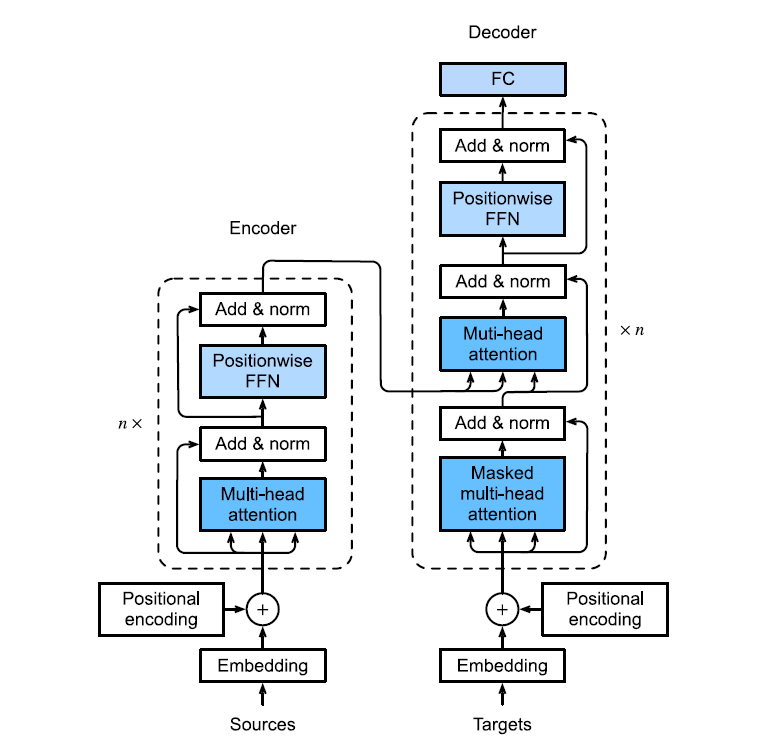

Both the encoder and the decoder consist of a stack of multiple identical blocks. The encoder block includes the first block of a multi-head self-attention pooling layer, followed by an *add & norm layer* (which plays a similar role as batch normalization layers in convolutional neural networks), followed by the second block of a *positionwise feed-forward network* and another *add & norm layer*. We also notice that all blocks include residual connections, as seen in several convolutional neural network architectures, such as ResNet. Note that this implies that *embed_size = attention_size*, which we will denote further in the code as *hidden_size*. The decoder is similar to the encoder; however, it has two separate attention blocks: a decoder self-attention block and an encoder–decoder attention block. 

Let us implement the two remaining elements: position-wise feed-forward network and add & norm layer first.

### Position-wise Feed-Forward Network <a class="anchor" id="pointwise_ffn"></a>

The position-wise feed-forward network transforms each sequence representation using the same dense layers at all positions (hence, it is called *position-wise* network).

In [81]:
class PositionWiseFFN(nn.Module): 
    
    def __init__(self, ffn_size, ffn_output_size):
        
        super().__init__()
        self.dense1 = nn.LazyLinear(ffn_size)
        self.relu = nn.ReLU()
        self.dense2 = nn.LazyLinear(ffn_output_size)
        
    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

We should note that in [[1](#1)] the dimensions were chosen as  *ffn_size* = 4*ffn_output_size* (namely, *ffn_output_size* = 512 and  *ffn_size* = 2048 ).

### Add & Norm Layer <a class="anchor" id="addnorm"></a>

The add & norm layer consists of *layer normalization*, which normalizes inputs across feature dimensions rather than within a minibatch (as in batch normalization). It turns out that layer normalization usually performs better in natural language processing tasks, where inputs are often variable-length sequences [[3](#3)]. Other than that, *Add & Norm Layer* includes the residual connection.

In [82]:
class AddNorm(nn.Module):
    
    def __init__(self, norm_shape, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(norm_shape)
    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

### Encoder <a class="anchor" id="encoder"></a>

Let us combine all the pieces and implement the transformer's encoder [[3](#3)].

In [83]:
class TransformerEncoderBlock(nn.Module): 
    
    def __init__(self, hidden_size, num_heads, ffn_size, dropout, use_bias = False):
        super().__init__()
        
        self.attention = MultiHeadAttention(hidden_size, num_heads, dropout, use_bias)
        self.addnorm1 = AddNorm(hidden_size, dropout)
        self.ffn = PositionWiseFFN(ffn_size, hidden_size)
        self.addnorm2 = AddNorm(hidden_size, dropout)
        
    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

We should note that token embeddings are multiplied by the square root of *embed_size* [[1](#1), [3](#3)].

In [84]:
class TransformerEncoder(nn.Module):
    
    def __init__(self, vocab_size, hidden_size, num_heads, ffn_size, num_blks, dropout, use_bias = False):
        super().__init__()
        
        self.hidden_size = hidden_size
        
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.pos_encoding = PositionalEncoding(hidden_size, dropout)
        self.blks = nn.Sequential()
        
        for i in range(num_blks):
            self.blks.add_module("block"+str(i), TransformerEncoderBlock(hidden_size, num_heads, ffn_size, dropout, use_bias))
            
    def forward(self, X, valid_lens):
        
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.hidden_size)) 
        self.attention_weights = [None] * len(self.blks)
        
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[i] = blk.attention.attention.attention_weights
            
        return X

Let us check our implementation.

In [85]:
for X, Y, X_len, Y_len in Tatoeba_dataset.train_dataloader:
    break
    
encoder = TransformerEncoder(vocab_size_1, hidden_size = 256, num_heads = 8, ffn_size = 4*256, num_blks = 2, dropout = 0.5)

In [86]:
encoder(X,X_len).size()

torch.Size([250, 16, 256])

In [87]:
encoder.attention_weights[0].size()

torch.Size([2000, 16, 16])

In [88]:
encoder.attention_weights[1].size()

torch.Size([2000, 16, 16])

### Decoder <a class="anchor" id="encoder"></a>

Let us go step by step through calculations in the transformer's decoder in the training mode. We first load the batch and process the input sequence via the encoder.

In [89]:
for X, Y, X_len, Y_len in Tatoeba_dataset.train_dataloader:
    break
    
encoder = TransformerEncoder(vocab_size_1, hidden_size = 256, num_heads = 8, ffn_size = 4*256, num_blks = 2, dropout = 0.5)

enc_output = encoder(X, X_len)
enc_output.size()

torch.Size([250, 16, 256])

We are evaluating the decoder in the training regime first. Hence, the decoder's input is the target sequence. We first need to compute the embeddings. 

In [90]:
hidden_size = 256
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()
dropout = 0 

dec_embedding = nn.Embedding(vocab_size_2, hidden_size)
pos_encoding = PositionalEncoding(hidden_size, dropout)

embed_Y = pos_encoding(dec_embedding(Y[:,:-1]) * math.sqrt(hidden_size)) 
embed_Y.size()

torch.Size([250, 16, 256])

The next step is a self-attention subblock. 

In [91]:
self_attention = MultiHeadAttention(hidden_size, num_heads, dropout)
addnorm1 = AddNorm(hidden_size, dropout)

However, unlike in the encoder, we need to employ a mask in the attention computations because the full target sequences are not available during inference (we cannot attend to future tokens that would not be known at that moment).

In [92]:
batch_size, input_length, _ = embed_Y.shape
dec_valid_lens = torch.arange(1, input_length + 1, device = embed_Y.device).repeat(batch_size, 1)
dec_valid_lens

tensor([[ 1,  2,  3,  ..., 14, 15, 16],
        [ 1,  2,  3,  ..., 14, 15, 16],
        [ 1,  2,  3,  ..., 14, 15, 16],
        ...,
        [ 1,  2,  3,  ..., 14, 15, 16],
        [ 1,  2,  3,  ..., 14, 15, 16],
        [ 1,  2,  3,  ..., 14, 15, 16]])

In [93]:
attention_values_1 = self_attention(embed_Y, embed_Y, embed_Y, dec_valid_lens)
attention_values_1.size()                           

torch.Size([250, 16, 256])

Next, we apply the add & norm layer.

In [94]:
output_1 = addnorm1(embed_Y, attention_values_1)
output_1.size()  

torch.Size([250, 16, 256])

The second subblock is the attention with the encoder outputs.

In [95]:
enc_attention = MultiHeadAttention(hidden_size, num_heads, dropout)
addnorm2 = AddNorm(hidden_size, dropout)

attention_values_2 = enc_attention(output_1, enc_output, enc_output, X_len)
output_2 = addnorm1(output_1, attention_values_2)
output_2.size()  

torch.Size([250, 16, 256])

The third subblock consists of a position-wise feed-forward network and another add & norm layer.

In [96]:
ffn_size = 4*hidden_size
ffn = PositionWiseFFN(ffn_size, hidden_size)
addnorm3 = AddNorm(hidden_size, dropout)

output_3 = addnorm3(output_2, ffn(output_2))
output_3.size()

torch.Size([250, 16, 256])

We successfully performed the operation in the first block. These operations would now repeat. 

In [97]:
self_attention_2 = MultiHeadAttention(hidden_size, num_heads, dropout)
addnorm1_2 = AddNorm(hidden_size, dropout)

attention_values_1_2 = self_attention(output_3, output_3, output_3, dec_valid_lens)
output_1_2 = addnorm1(output_3, attention_values_1_2)
output_1_2.size()

torch.Size([250, 16, 256])

And so on.

Lastly, there is a linear layer that will turn these outputs into probability logits, which predict the value of the next token in the sequence.

In [98]:
linear = nn.LazyLinear(vocab_size_2)
linear(output_1_2).size()

torch.Size([250, 16, 9634])

Overall, we get the following implementation [[3](#3)].

In [99]:
class TransformerDecoderBlock(nn.Module):

    def __init__(self, hidden_size, ffn_size, num_heads, dropout, i):
        super().__init__()

        self.attention1 = MultiHeadAttention(hidden_size, num_heads, dropout)
        self.addnorm1 = AddNorm(hidden_size, dropout)
        self.attention2 = MultiHeadAttention(hidden_size, num_heads, dropout)
        self.addnorm2 = AddNorm(hidden_size, dropout)
        self.ffn = PositionWiseFFN(ffn_size, hidden_size)
        self.addnorm3 = AddNorm(hidden_size, dropout)
        
    def forward(self, X, state):
        
        enc_outputs, enc_valid_lens = state[0], state[1]
        batch_size, num_steps, _ = X.shape
        dec_valid_lens = torch.arange(1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        
        #if training:
        #    batch_size, num_steps, _ = X.shape
        #    dec_valid_lens = torch.arange(1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        #else:
        #    dec_valid_lens = None
            
        # Self-attention
        X2 = self.attention1(X, X, X, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        
        # Encoder-decoder attention. Shape of enc_outputs: (batch_size, num_steps, num_hiddens)
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        
        return self.addnorm3(Z, self.ffn(Z)), state

In [100]:
class TransformerDecoder(nn.Module):
    
    def __init__(self, vocab_size, hidden_size, num_heads, ffn_size, num_blks, dropout):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.num_blks = num_blks
        
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.pos_encoding = PositionalEncoding(hidden_size, dropout)
        self.blks = nn.Sequential()
        
        for i in range(num_blks):
            self.blks.add_module("block"+str(i), TransformerDecoderBlock(hidden_size, ffn_size, num_heads, dropout, i))
            
        self.linear = nn.LazyLinear(vocab_size)

    def forward(self, X, state):
        
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.hidden_size))
        self._attention_weights = [[None] * len(self.blks) for _ in range (2)]
        
        for i, blk in enumerate(self.blks):
            
            X, state = blk(X, state)
            
            # Decoder self-attention weights
            self._attention_weights[0][i] = blk.attention1.attention.attention_weights
            
            # Encoder-decoder attention weights
            self._attention_weights[1][i] = blk.attention2.attention.attention_weights
            
        return self.linear(X), state
    
    @property
    def attention_weights(self):
        return self._attention_weights

### Transformer Implementation <a class="anchor" id="transformer_impl"></a>

We can combine the encoder and decoder implementations to obtain the transformer [[3](#3)].

In [101]:
class Transformer(nn.Module):
    def __init__(self, vocab_size,  hidden_size, num_heads, ffn_size, num_blks, dropout = 0):
        super().__init__()

        self.encoder = TransformerEncoder(vocab_size[0], hidden_size = hidden_size, num_heads = num_heads, ffn_size = ffn_size, num_blks = num_blks, dropout = dropout)
        self.decoder = TransformerDecoder(vocab_size[1], hidden_size = hidden_size, num_heads = num_heads, ffn_size = ffn_size, num_blks = num_blks, dropout = dropout)

    def forward(self, input_X, input_Y, X_len):
        
        enc_output = self.encoder(input_X, X_len)
        dec_output, _ = self.decoder(input_Y, [enc_output, X_len]) 

        return dec_output.permute(1, 0, 2) # permute outputs so that the dimensions are in line with our other encoder-decoder models

In [102]:
transformer = Transformer([vocab_size_1, vocab_size_2], hidden_size = 256, num_heads = 8, ffn_size = 4*256, num_blks = 2, dropout = 0.2)

In [103]:
for X, Y, X_len, Y_len in Tatoeba_dataset.train_dataloader:
    break
output = transformer(X, Y[:,:-1], X_len)

In [104]:
output.size()

torch.Size([16, 250, 9634])

During inference (aka prediction), we iteratively feed the decoder the predicted sequence (starting with the *\<bos\>* token), i.e., we predict the next token one at a time, which is actually a bit similar to an RNN. This makes inference with the transformer quite a bit more expensive than training, which only required a single pass through the network.

We should note that we had to slightly rewrite the beam search implementation to accommodate the transformer's different structure compared to the RNN-based encoder-decoder networks.

In [105]:
def predict_greedy_transformer(model, input_X, input_Y_init, X_len, num_steps):

    with torch.no_grad():
        
        prefix = input_Y_init
        enc_output = model.encoder(input_X, X_len)
        
        for i in range(num_steps): 

            output, _ = model.decoder(prefix, [enc_output, X_len])
            input_Y = output[:,-1,:].argmax()[None][None]
            prefix = torch.cat((prefix,input_Y),1).flatten()[None]

        return prefix

In [106]:
bos_token = torch.tensor(Tatoeba_dataset.vocab_lang_2['<bos>'])
bos_token = bos_token[None][None]

greedy_pred = predict_greedy_transformer(transformer, X[0][None,:], bos_token, X_len[0][None], 10)
Tatoeba_dataset.vocab_lang_2.to_tokens(greedy_pred[0])

['<bos>',
 'brambor',
 'došla',
 'vyfocených',
 'jezdíš',
 'naproti',
 'bavil',
 'pohodlně',
 'většinou',
 'žába',
 'rozebírat']

In [107]:
def predict_beam_transformer(model, input_X, input_Y_init, X_len, num_steps, beam_size):

        with torch.no_grad():

            # predicted sequences
            pred_token_seq = torch.zeros([beam_size, num_steps + 1], device = input_X.device).long()
            pred_token_seq[:,0] = input_Y_init
            
            enc_output = model.encoder(input_X, X_len)
            output, _ = model.decoder(input_Y_init, [enc_output, X_len])

            sort_by_prob = torch.sort(torch.nn.functional.softmax(output.flatten(), dim = 0),descending  = True)

            
            pred_token_seq[:,1] = sort_by_prob[1][:beam_size]
            prob_seq = sort_by_prob[0][:beam_size]

            # encoder output
            enc_output_seq = enc_output.repeat([beam_size,1,1])
            X_len_seq = X_len.repeat([beam_size])
            
            for i in range(1, num_steps):
            
                outputs, _ = model.decoder(pred_token_seq[:,:i+1], [enc_output_seq, X_len_seq])

                pred_token_seq_new = torch.zeros([beam_size, num_steps+1], device = input_X.device).long() 

                output_0_sort_by_prob = torch.sort(torch.nn.functional.softmax(outputs[0,-1,:].flatten(), dim = 0),descending  = True)

                pred_token_seq_new[:,0:i+1] =  pred_token_seq[0,0:i+1]
                pred_token_seq_new[:,i+1] = output_0_sort_by_prob[1][:beam_size]
                
                prob_seq_new = prob_seq[0]*output_0_sort_by_prob[0][:beam_size]

                for j in range(1, beam_size):
                
                    output_j_sort_by_prob = torch.sort(torch.nn.functional.softmax(outputs[j,-1,:].flatten(), dim = 0),descending  = True)

                    for k in range(beam_size):

                        prob_cand = prob_seq[j]*output_j_sort_by_prob[0][k]
                    
                        for l in range(beam_size):
                        
                            if prob_cand > prob_seq_new[l]:
                                prob_seq_new[l] = prob_cand
                                pred_token_seq_new[l,0:i+1] = pred_token_seq[j,0:i+1]
                                pred_token_seq_new[l,i+1] = output_j_sort_by_prob[1][k]
                                break

                        if (l == beam_size):
                            break
                            
                prob_seq = prob_seq_new
                pred_token_seq = pred_token_seq_new
                
        # return outputs, states
        return pred_token_seq, prob_seq 

In [108]:
bos_token = torch.tensor(Tatoeba_dataset.vocab_lang_2['<bos>'])
bos_token = bos_token[None][None]

greedy_pred, _ = predict_beam_transformer(transformer, X[0][None,:], bos_token, X_len[0][None], 10, 5)
Tatoeba_dataset.vocab_lang_2.to_tokens(greedy_pred[0])

['<bos>',
 'basketbal',
 'čaje',
 'vyrostl',
 'odjede',
 'podrobnosti',
 'střehu',
 'navzdory',
 '<unk>',
 'zničilo',
 'tito']

We should note that in practice, since we are feeding the same tokens over and over during predictions, we can implement *KV Caching*, which stores keys and values for the generated tokens to be reused later, saving some computational time.

Let us now train the transformer on English-Czech sentence pairs.

In [109]:
torch.manual_seed(123)

# data loader
Tatoeba_dataset = Tatoeba('D:/nine circles 2/ces.txt', num_train = 38000, batch_size = 250, max_length = 15) 
Tatoeba_train_loader = Tatoeba_dataset.train_dataloader
Tatoeba_test_loader = Tatoeba_dataset.test_dataloader


vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()

hidden_size = 256
num_blks = 2
ffn_size = 4*hidden_size
num_heads = 8


transformer_cuda = Transformer([vocab_size_1, vocab_size_2], hidden_size = hidden_size, num_heads = num_heads, ffn_size = ffn_size, num_blks = num_blks, dropout = 0).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(transformer_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[100], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
max_norm = 10000

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(Tatoeba_train_loader, Tatoeba_test_loader, transformer_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

2127.5963065624237


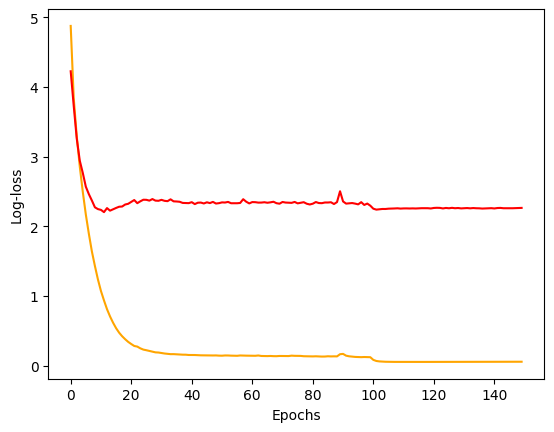

In [110]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [111]:
loss_epochs_train[149]

0.054530248045921326

In [112]:
loss_epochs_test[149]

2.262463331222534

In [113]:
loss_epochs_test.min()

2.201674222946167

It seems that our model would benefit from a bit of regularization (we will increase dropout from 0 to 0.1).

In [114]:
torch.manual_seed(123)

# data loader
Tatoeba_dataset = Tatoeba('D:/nine circles 2/ces.txt', num_train = 38000, batch_size = 250, max_length = 15) 
Tatoeba_train_loader = Tatoeba_dataset.train_dataloader
Tatoeba_test_loader = Tatoeba_dataset.test_dataloader


vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()

hidden_size = 256
num_blks = 2
ffn_size = 4*hidden_size
num_heads = 8


transformer_cuda = Transformer([vocab_size_1, vocab_size_2], hidden_size = hidden_size, num_heads = num_heads, ffn_size = ffn_size, num_blks = num_blks, dropout = 0.1).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(transformer_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[100], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
max_norm = 10000

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(Tatoeba_train_loader, Tatoeba_test_loader, transformer_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

2155.431655406952


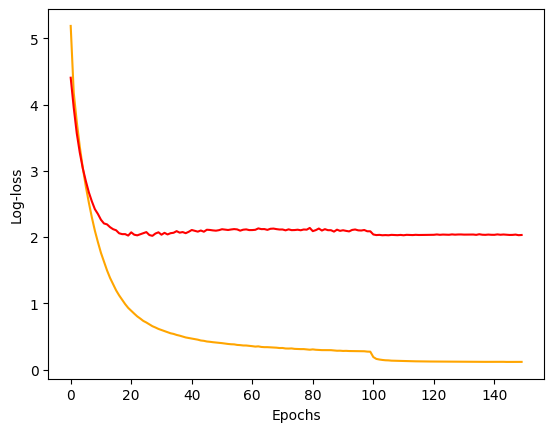

In [115]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [116]:
loss_epochs_train[149]

0.11734789609909058

In [117]:
loss_epochs_test[149]

2.0316884517669678

In [118]:
loss_epochs_test.min()

2.0188560485839844

In [119]:
bleu_score = []

for X, Y, X_len, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq = predict_greedy_transformer(transformer_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[i][None].to(cuda_device), num_steps = 15)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [120]:
sum(bleu_score)/len(bleu_score)

0.3576259464105422

In [121]:
bleu_score = []

for X, Y, X_len, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq, _ = predict_beam_transformer(transformer_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[i][None].to(cuda_device), num_steps = 15, beam_size = 5)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [122]:
sum(bleu_score)/len(bleu_score)

0.3712180304845765

We observe that the transformer model is significantly better than our earlier RNN-based encoder-decoder with additive attention. We reduced the log-loss from 2.425 to 2.07 and increased BLEU from 0.320 to 0.357.

In [123]:
torch.manual_seed(123)

# data loader
Tatoeba_dataset = Tatoeba('D:/nine circles 2/fra.txt', num_train = 220000, batch_size = 250, max_length = 15) 
Tatoeba_train_loader = Tatoeba_dataset.train_dataloader
Tatoeba_test_loader = Tatoeba_dataset.test_dataloader


vocab_size_1 = Tatoeba_dataset.vocab_lang_1.__len__()
vocab_size_2 = Tatoeba_dataset.vocab_lang_2.__len__()

hidden_size = 256
num_blks = 4
ffn_size = 4*hidden_size
num_heads = 8


transformer_cuda = Transformer([vocab_size_1, vocab_size_2], hidden_size = hidden_size, num_heads = num_heads, ffn_size = ffn_size, num_blks = num_blks, dropout = 0.1).to(cuda_device)

optim_SGD_cuda =  torch.optim.SGD(transformer_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[100], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(reduction='none')
max_norm = 10000

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(Tatoeba_train_loader, Tatoeba_test_loader, transformer_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

14839.837365627289


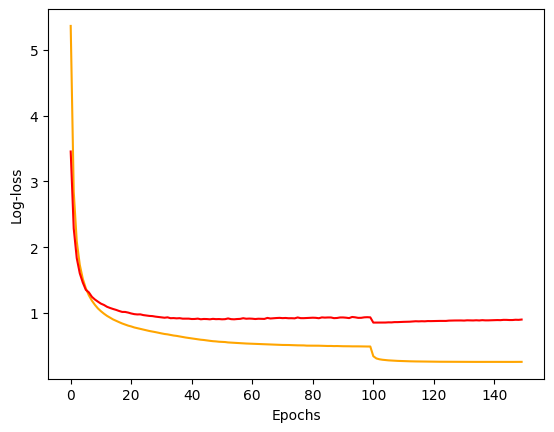

In [124]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [125]:
loss_epochs_train[149]

0.2582520544528961

In [126]:
loss_epochs_test[149]

0.9013091921806335

In [127]:
loss_epochs_test.min()

0.8537254929542542

In [128]:
bos_token = torch.tensor(Tatoeba_dataset.vocab_lang_2['<bos>'])
bos_token = bos_token[None][None]

bleu_score = []

for X, Y, X_len, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq = predict_greedy_transformer(transformer_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[i][None].to(cuda_device), num_steps = 15)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)

In [129]:
sum(bleu_score)/len(bleu_score)

0.6293969093649395

In [130]:
bos_token = torch.tensor(Tatoeba_dataset.vocab_lang_2['<bos>'])
bos_token = bos_token[None][None]

bleu_score = []

for X, Y, X_len, Y_len in Tatoeba_dataset.test_dataloader:
    
    for i in range(len(X)):
        
        pred_token_seq, _ = predict_beam_transformer(transformer_cuda, X[i][None,:].to(cuda_device), bos_token.to(cuda_device), X_len[i][None].to(cuda_device), num_steps = 15, beam_size = 5)
        pred_token_seq = Tatoeba_dataset.vocab_lang_2.to_tokens(pred_token_seq[0])
        
        try:
            idx = pred_token_seq.index('<eos>')
        except:
            idx = len(pred_token_seq)
            
        pred_token_seq = pred_token_seq[:idx]
        if len(pred_token_seq) > 0:
            bleu_score.append(BLEU(pred_token_seq, Tatoeba_dataset.vocab_lang_2.to_tokens(Y[i][1:Y_len[i]]), 3))
        else:
            bleu_score.append(0)   

In [131]:
sum(bleu_score)/len(bleu_score)

0.6359017262165162

All metrics are significantly better than any we have obtained from the models with RNN-based architectures.  

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> VASWANI, Ashish, et al. Attention is all you need. *Advances in neural information processing systems*, 2017, 30.

<a id="2">[2]</a> BAHDANAU, Dzmitry; CHO, Kyunghyun; BENGIO, Yoshua. Neural machine translation by jointly learning to align and translate. *arXiv preprint arXiv:1409.0473*, 2014.

<a id="3">[3]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.